# Ensemble Learning for Chronic Kidney Disease
### Student Notebook (Fill in the Missing Code)

This notebook guides you through building machine learning models to predict Chronic Kidney Disease.
Complete the missing code sections marked with `# TODO`.

* Dealing with class imbalance

https://www.analyticsvidhya.com/blog/2020/07/10-techniques-to-deal-with-class-imbalance-in-machine-learning/

## 1. Import Libraries

In [ ]:
# TODO: Import required libraries
# pandas, numpy, sklearn modules, matplotlib, seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [ ]:
# TODO: Load the dataset 'Chronic_Kidney_Dsease_data.csv'
# Display the first 5 rows
df = pd.read_csv('Chronic_Kidney_Dsease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


## 3. Explore Dataset

In [ ]:
# TODO:
# 1. Print dataset shape
# 2. Display column names
# 3. Check for missing values
print(df.shape)
print('------------------------------------------------------------')
print(df.columns)
print('-------------------------------------------------------------')
print(df.isnull().sum())

(1659, 54)
------------------------------------------------------------
Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus',
       'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension',
       'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury',
       'UrinaryTractInfections', 'SystolicBP', 'DiastolicBP',
       'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR',
       'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium',
       'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium',
       'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
       'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins',
       'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting',
       'MuscleCramps', 'Itching', 'QualityOfLifeScore',

## 4. Data Cleaning

In [ ]:
# TODO:
# Remove unnecessary columns such as PatientID and DoctorInCharge
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)

## 5. Feature and Target Split

In [ ]:
# TODO:
# Separate dataset into X (features) and y (target variable 'Diagnosis')
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

## 6. Train-Test Split

In [ ]:
# TODO:
# Split the data into training and testing sets (e.g., 80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 7. Feature Scaling

In [ ]:
# TODO:
# Apply StandardScaler to normalize feature values
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


## 8. Train Logistic Regression Model

In [ ]:
# TODO:
# Train a Logistic Regression model
# Make predictions on the test set
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 9. Train Random Forest Model

In [ ]:
# TODO:
# Train a Random Forest model
# Make predictions on the test set
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

## 10. Model Evaluation

Logistic Regression Model Evaluation:
Accuracy: 0.9367
Precision: 0.9415
Recall: 0.9935
F1-score: 0.9668
Confusion Matrix:


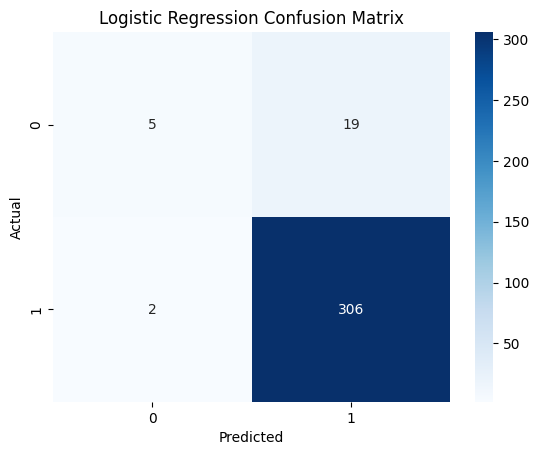


Random Forest Model Evaluation:
Accuracy: 0.9307
Precision: 0.9305
Recall: 1.0000
F1-score: 0.9640
Confusion Matrix:


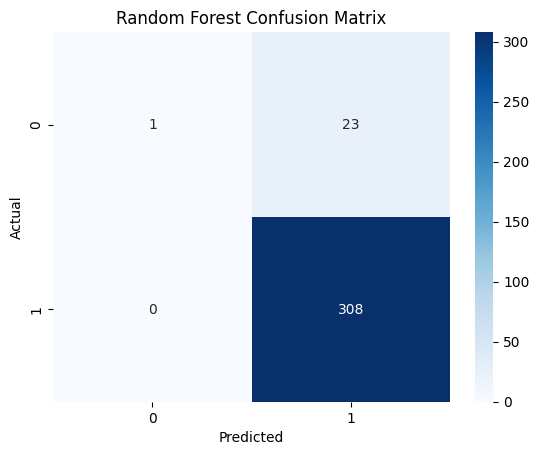

In [ ]:
# TODO:
# Calculate Accuracy, Precision, Recall, F1-score
# Display a confusion matrix

print('Logistic Regression Model Evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred):.4f}')
print('Confusion Matrix:')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('\nRandom Forest Model Evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_rf):.4f}')
print('Confusion Matrix:')
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 11. Ensemble Learning - Stacking


Stacking Model Evaluation:
Accuracy: 0.9277
Precision: 0.9303
Recall: 0.9968
F1-score: 0.9624
Confusion Matrix:


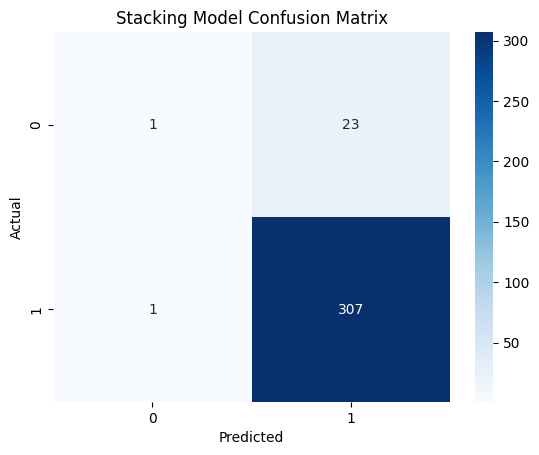

In [ ]:
# TODO:
# Create a StackingClassifier using Logistic Regression and Random Forest
# Train the stacking model
# Evaluate performance
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define base models
estimators = [
    ('lr', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
]

# Create StackingClassifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5 # Cross-validation folds
)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_stack = stacking_model.predict(X_test)

# Evaluate performance
print('\nStacking Model Evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_stack):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_stack):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_stack):.4f}')
print('Confusion Matrix:')
sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d', cmap='Blues')
plt.title('Stacking Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 12. Handling Class Imbalance

Applying SMOTE for Class Imbalance Handling...
Original training set shape: (1327, 51), (1327,)
Resampled training set shape: (2432, 51), (2432,)
Resampled target distribution:
Diagnosis
1    1216
0    1216
Name: count, dtype: int64

Retraining Logistic Regression with SMOTE...

Logistic Regression Model Evaluation (with SMOTE):
Accuracy: 0.8042
Precision: 0.9585
Recall: 0.8247
F1-score: 0.8866
Confusion Matrix:


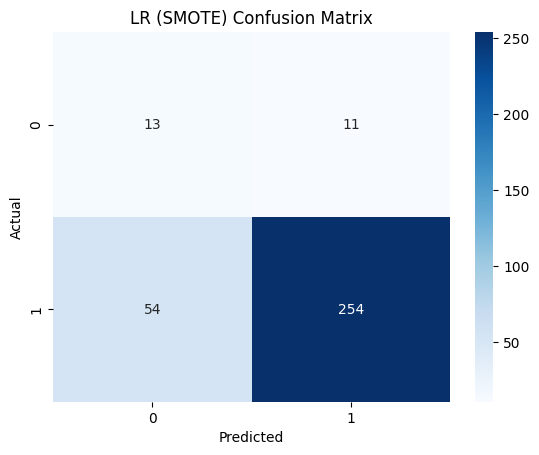


Retraining Random Forest with SMOTE...

Random Forest Model Evaluation (with SMOTE):
Accuracy: 0.9217
Precision: 0.9325
Recall: 0.9870
F1-score: 0.9590
Confusion Matrix:


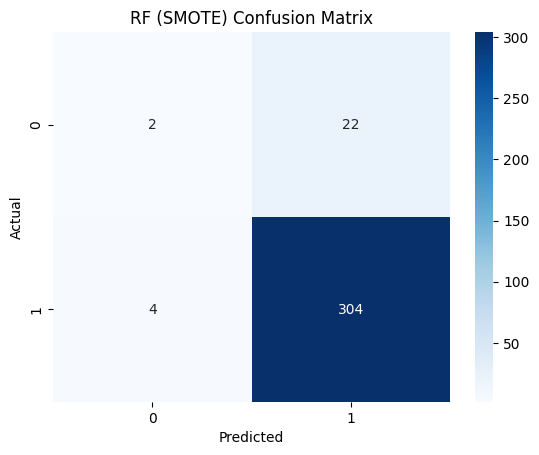


Retraining Stacking Model with SMOTE...

Stacking Model Evaluation (with SMOTE):
Accuracy: 0.9217
Precision: 0.9325
Recall: 0.9870
F1-score: 0.9590
Confusion Matrix:


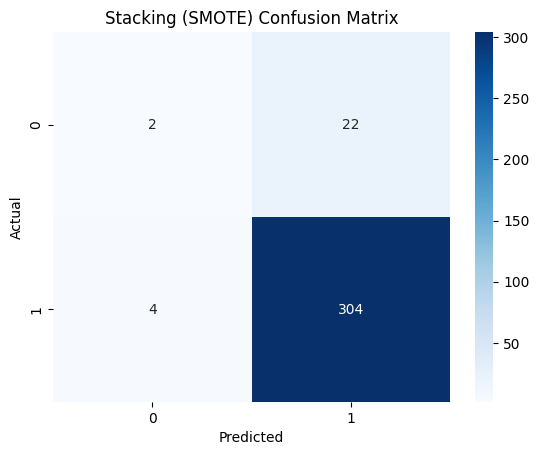

In [ ]:
# TODO:
# Apply oversampling (e.g., SMOTE) or undersampling
# Retrain models and compare performance
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Applying SMOTE for Class Imbalance Handling...')
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print(f'Original training set shape: {X_train.shape}, {y_train.shape}')
print(f'Resampled training set shape: {X_train_resampled.shape}, {y_train_resampled.shape}')
print(f'Resampled target distribution:\n{y_train_resampled.value_counts()}')

# Retrain Logistic Regression Model with resampled data
print('\nRetraining Logistic Regression with SMOTE...')
model_resampled_lr = LogisticRegression(random_state=42)
model_resampled_lr.fit(X_train_resampled, y_train_resampled)
y_pred_resampled_lr = model_resampled_lr.predict(X_test)

print('\nLogistic Regression Model Evaluation (with SMOTE):')
print(f'Accuracy: {accuracy_score(y_test, y_pred_resampled_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_resampled_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_resampled_lr):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_resampled_lr):.4f}')
print('Confusion Matrix:')
sns.heatmap(confusion_matrix(y_test, y_pred_resampled_lr), annot=True, fmt='d', cmap='Blues')
plt.title('LR (SMOTE) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Retrain Random Forest Model with resampled data
print('\nRetraining Random Forest with SMOTE...')
model_resampled_rf = RandomForestClassifier(random_state=42)
model_resampled_rf.fit(X_train_resampled, y_train_resampled)
y_pred_resampled_rf = model_resampled_rf.predict(X_test)

print('\nRandom Forest Model Evaluation (with SMOTE):')
print(f'Accuracy: {accuracy_score(y_test, y_pred_resampled_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_resampled_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_resampled_rf):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_resampled_rf):.4f}')
print('Confusion Matrix:')
sns.heatmap(confusion_matrix(y_test, y_pred_resampled_rf), annot=True, fmt='d', cmap='Blues')
plt.title('RF (SMOTE) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Retrain Stacking Model with resampled data
print('\nRetraining Stacking Model with SMOTE...')
estimators_resampled = [
    ('lr', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
]
stacking_model_resampled = StackingClassifier(
    estimators=estimators_resampled,
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)
stacking_model_resampled.fit(X_train_resampled, y_train_resampled)
y_pred_resampled_stack = stacking_model_resampled.predict(X_test)

print('\nStacking Model Evaluation (with SMOTE):')
print(f'Accuracy: {accuracy_score(y_test, y_pred_resampled_stack):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_resampled_stack):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_resampled_stack):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_resampled_stack):.4f}')
print('Confusion Matrix:')
sns.heatmap(confusion_matrix(y_test, y_pred_resampled_stack), annot=True, fmt='d', cmap='Blues')
plt.title('Stacking (SMOTE) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 13. Final Comparison

In [ ]:
# TODO:
# Create a table comparing performance of:
# Logistic Regression
# Random Forest
# Stacking Model

results = {
    'Model': ['Logistic Regression (No SMOTE)', 'Random Forest (No SMOTE)', 'Stacking (No SMOTE)',
              'Logistic Regression (SMOTE)', 'Random Forest (SMOTE)', 'Stacking (SMOTE)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_stack),
        accuracy_score(y_test, y_pred_resampled_lr),
        accuracy_score(y_test, y_pred_resampled_rf),
        accuracy_score(y_test, y_pred_resampled_stack)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_stack),
        precision_score(y_test, y_pred_resampled_lr),
        precision_score(y_test, y_pred_resampled_rf),
        precision_score(y_test, y_pred_resampled_stack)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_stack),
        recall_score(y_test, y_pred_resampled_lr),
        recall_score(y_test, y_pred_resampled_rf),
        recall_score(y_test, y_pred_resampled_stack)
    ],
    'F1-score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_stack),
        f1_score(y_test, y_pred_resampled_lr),
        f1_score(y_test, y_pred_resampled_rf),
        f1_score(y_test, y_pred_resampled_stack)
    ]
}

comparison_df = pd.DataFrame(results)
print(comparison_df.round(4))


                            Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression (No SMOTE)    0.9367     0.9415  0.9935    0.9668
1        Random Forest (No SMOTE)    0.9307     0.9305  1.0000    0.9640
2             Stacking (No SMOTE)    0.9277     0.9303  0.9968    0.9624
3     Logistic Regression (SMOTE)    0.8042     0.9585  0.8247    0.8866
4           Random Forest (SMOTE)    0.9217     0.9325  0.9870    0.9590
5                Stacking (SMOTE)    0.9217     0.9325  0.9870    0.9590


## Reflection Questions
1. Which model performed best and why?
2. How did class imbalance affect model performance?
3. Why might ensemble methods improve prediction accuracy?

Thanks 😀

1-Logistic Regression without SMOTE achieved the best performance because it produced the highest F1-score and accuracy, indicating a strong balance between precision and recall while handling the imbalanced dataset effectively.







2-**Class imbalance affected model performance by biasing the model toward the majority class, causing poor prediction accuracy for the minority class and misleading overall accuracy.**





3- Ensemble methods improve prediction accuracy by **combining predictions from multiple models to reduce bias, reduce variance, and produce more robust and reliable results**.
